# K-Means Clustering Tutorial

**By Rebe**

Hey! This notebook teaches you K-Means clustering step by step. We'll cover what it is, how it works, and how to implement it on real data.

### 🛠️ Setup: Installing Libraries

We need a few libraries to work with data, visualize it, and run clustering:
- `ISLP`: Contains the NCI60 dataset
- `scikit-learn`: Has K-Means and PCA
- `pandas`, `matplotlib`, `seaborn`: Data handling and plotting

In [ ]:
!pip install ISLP

In [ ]:
import ISLP
nci60 = ISLP.load_data('NCI60')
X = nci60['data']
y = nci60['labels']

print("Dataset loaded successfully.")

Dataset loaded successfully.


### 📥 Loading the Dataset

We'll load the NCI60 dataset using ISLP library. This gives us:
- `X`: Feature matrix (60 cell lines × 6,144 genes)
- `y`: Labels (cell line types, for visualization only)

## Step 1: Load the Data

We're using the NCI60 dataset - 60 cancer cell lines with gene expression data. Let's load it and see what we're working with.

## NCI60 Dataset Characteristics

In [ ]:
print(f"Shape of X (features): {X.shape}")
print(f"Shape of y (labels): {y.shape}")
print(f"Number of unique labels: {len(y.value_counts())}")
print("Count of each label (cell line type):")
print(y.value_counts())

Shape of X (features): (64, 6830)
Shape of y (labels): (64, 1)
Number of unique labels: 14
Count of each label (cell line type):
label      
RENAL          9
NSCLC          9
MELANOMA       8
BREAST         7
COLON          7
LEUKEMIA       6
OVARIAN        6
CNS            5
PROSTATE       2
K562A-repro    1
K562B-repro    1
MCF7D-repro    1
MCF7A-repro    1
UNKNOWN        1
Name: count, dtype: int64


## Understanding the Data

Let's explore the shape and structure of our dataset. This tells us how many samples and features we have.

### 📊 Standardizing Data

`StandardScaler` transforms each feature to have mean=0 and std=1. This ensures all genes have equal weight in distance calculations, not just the ones with large numbers.

## NCI60 Dataset Characteristics

In [ ]:
print(f"Shape of X (features): {X.shape}")
print(f"Shape of y (labels): {y.shape}")
print(f"Number of unique labels: {len(y['label'].value_counts())}")
print("Count of each label (cell line type):")
print(y['label'].value_counts())

Shape of X (features): (64, 6830)
Shape of y (labels): (64, 1)
Number of unique labels: 14
Count of each label (cell line type):
label
RENAL          9
NSCLC          9
MELANOMA       8
BREAST         7
COLON          7
OVARIAN        6
LEUKEMIA       6
CNS            5
PROSTATE       2
UNKNOWN        1
K562B-repro    1
K562A-repro    1
MCF7A-repro    1
MCF7D-repro    1
Name: count, dtype: int64


## Visualizing Clusters with Raw Feature Pairs

### 🎯 Running K-Means Algorithm

Here we create a K-Means object and fit it to our data:
- `n_clusters=3`: We want 3 clusters
- `n_init=25`: Try 25 random starting points, keep the best
- `fit_predict()`: Fit the model AND get cluster assignments

## Step 2: Data Preprocessing

Before clustering, we need to standardize the features so they're all on the same scale.

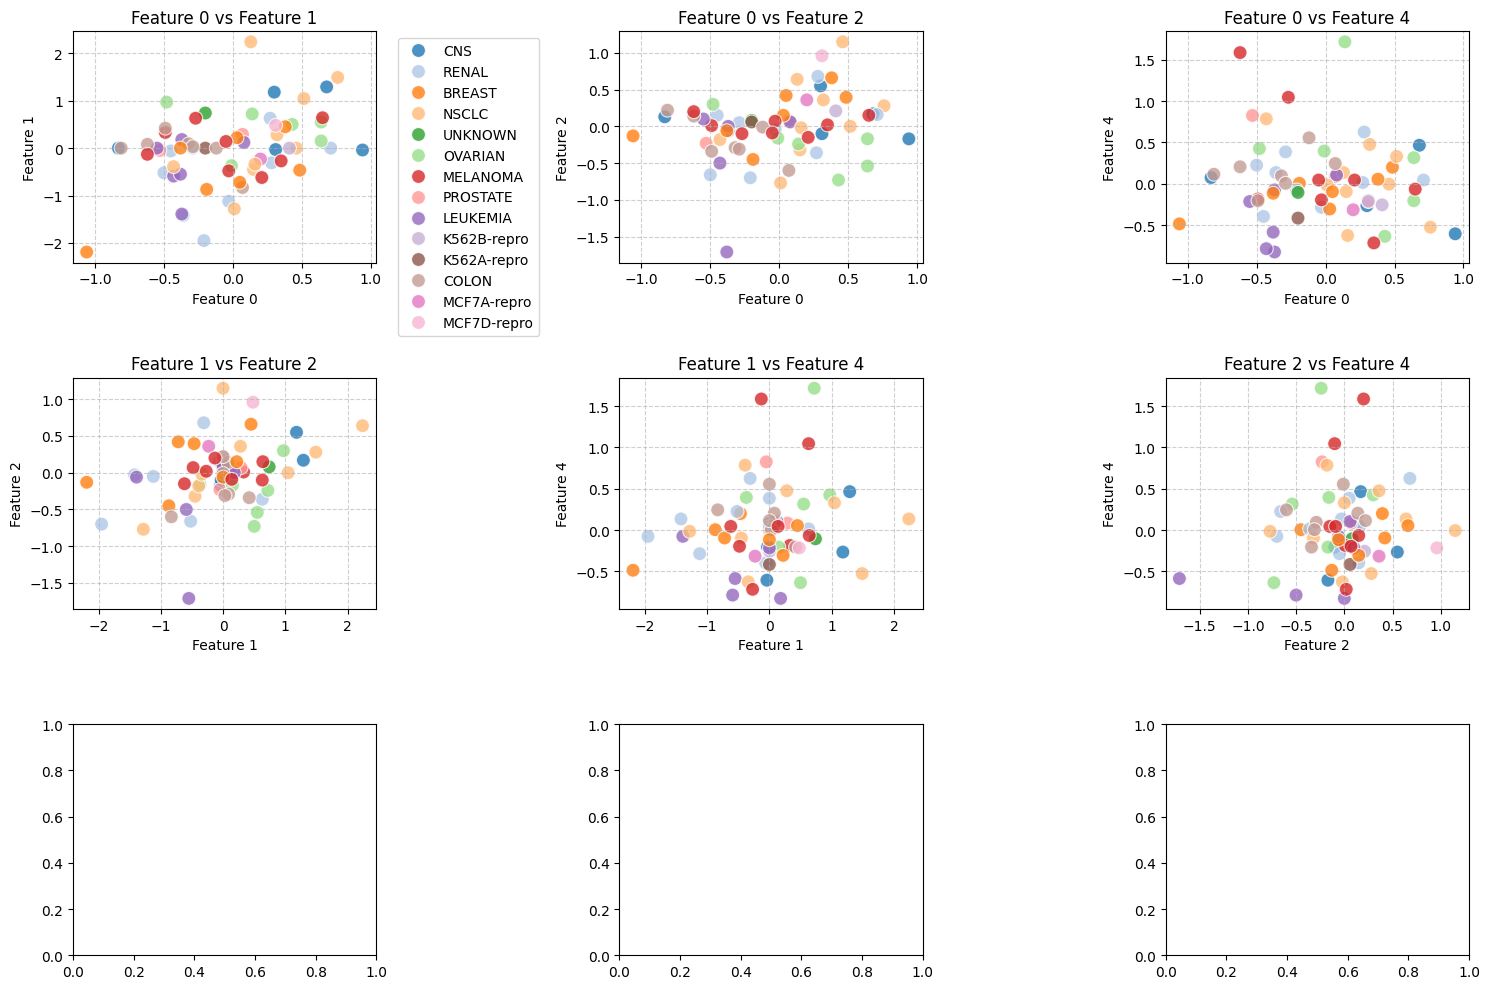

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Convert X to a DataFrame for easier column selection and plotting
X_df = pd.DataFrame(X)
X_df['Cell Line'] = y['label'].values  # Add labels to the DataFrame

# Select a few features to plot. For demonstration, let's pick the first three.
selected_features = [0, 1, 2, 4] # Indices of the features to plot
feature_names = [f'Feature {i}' for i in selected_features]

# Create pairwise scatter plots for the selected features
fig, axes = plt.subplots(len(selected_features)-1, len(selected_features)-1, figsize=(15, 10))
axes = axes.flatten() # Flatten the array of axes for easy iteration

plot_idx = 0
for i in range(len(selected_features)):
    for j in range(i + 1, len(selected_features)):
        if plot_idx < len(axes):
            sns.scatterplot(
                x=X_df[selected_features[i]],
                y=X_df[selected_features[j]],
                hue=X_df['Cell Line'],
                palette='tab20',
                s=100,
                alpha=0.8,
                ax=axes[plot_idx]
            )
            axes[plot_idx].set_title(f'{feature_names[i]} vs {feature_names[j]}')
            axes[plot_idx].set_xlabel(feature_names[i])
            axes[plot_idx].set_ylabel(feature_names[j])
            axes[plot_idx].grid(True, linestyle='--', alpha=0.6)
            if plot_idx == 0: # Only show legend once
                axes[plot_idx].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
            else:
                axes[plot_idx].get_legend().remove()
            plot_idx += 1

plt.tight_layout()
plt.show()

### 📈 Reducing Dimensions with PCA

`PCA` projects our 6,144-dimensional data into 2D space while keeping the variance (important patterns). This lets us visualize clusters on a 2D plot.

These plots display the relationships between selected pairs of original features, with points colored by their cell line type. By examining these, you can observe if specific cell lines tend to form distinct groupings in the 2D space defined by these feature pairs. This approach helps in understanding the raw feature-level separation of classes without any data transformation.

## K-Means Clustering and Visualization (2 Clusters)

In [ ]:
from sklearn.cluster import KMeans

# Perform K-Means clustering
kmeans = KMeans(n_clusters=2, n_init=25, random_state=42) # n_init=25 as requested
kmeans_labels = kmeans.fit_predict(X)

print(f"K-Means clustering performed with {kmeans.n_clusters} clusters.")
print("Cluster assignments:")
print(pd.Series(kmeans_labels).value_counts())

K-Means clustering performed with 2 clusters.
Cluster assignments:
0    43
1    21
Name: count, dtype: int64


## Step 3: Running K-Means

Now we apply the K-Means algorithm. This will find clusters in our data. 
Under the hood, the algorithm follows this simple loop:

1. INITIALIZE: Randomly place K centroids in the data space.
2. REPEAT until the centroids stop moving:
    
    ### Step A: Assignment
    FOR each data point:
        Calculate distance to all K centroids
        Assign the point to the closest centroid's cluster
        
    ### Step B: Update
    FOR each cluster:
        Calculate the mean (center) of all points inside it
        Move the centroid to this new center coordinate

## Visualizing K-Means Clusters (2 Clusters)

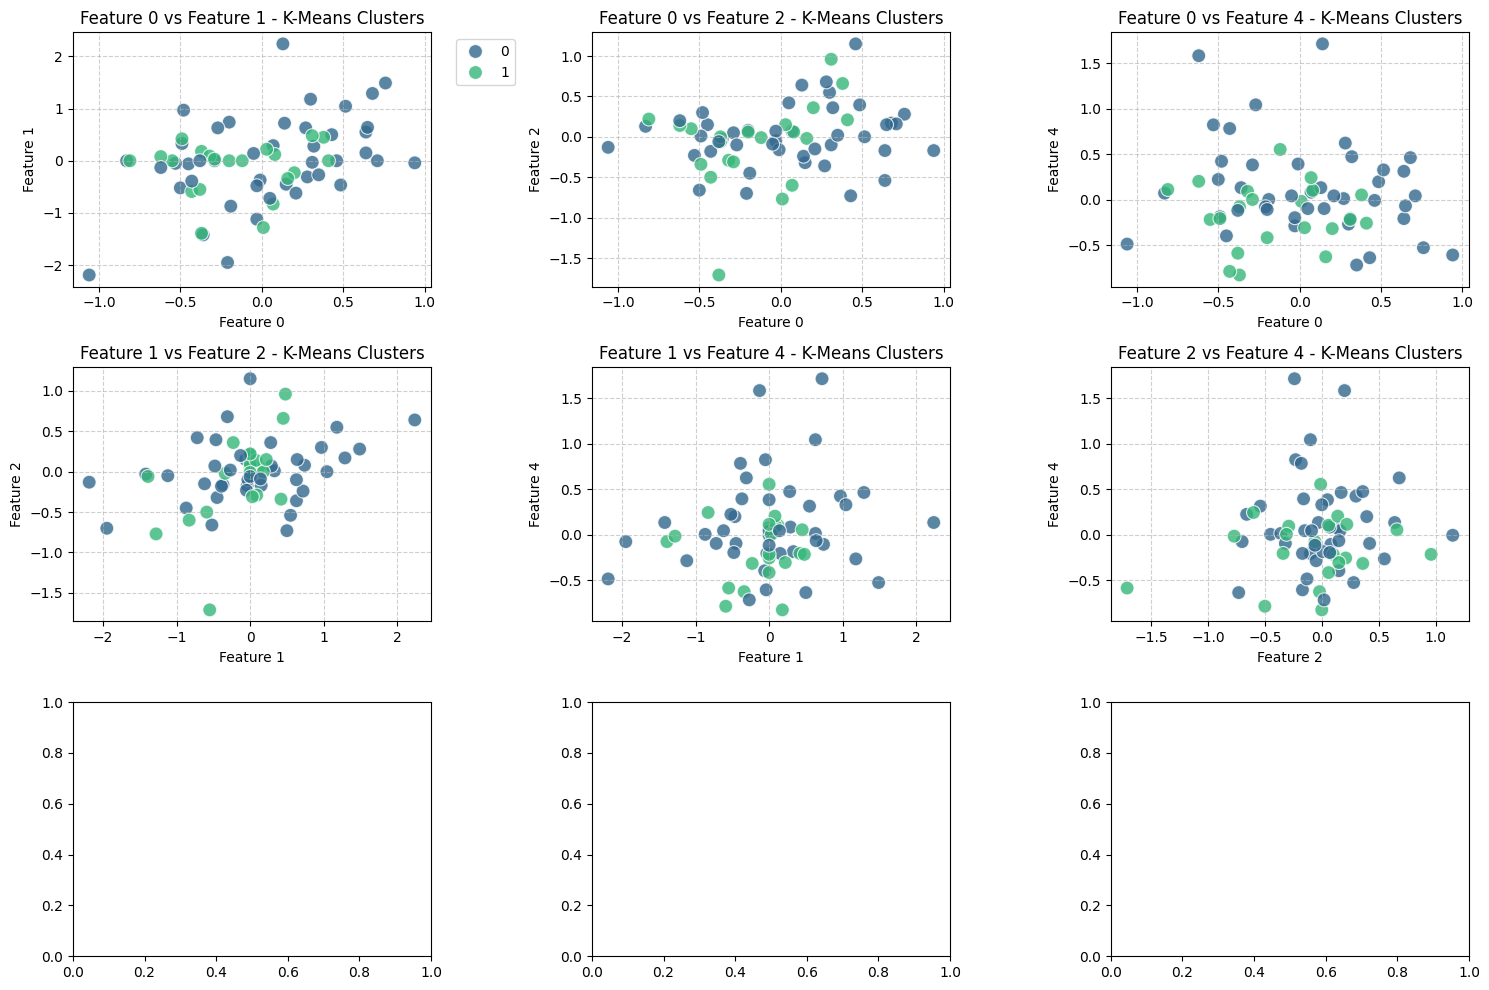

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a DataFrame for plotting K-Means clusters, using the same selected features
kmeans_plot_df = X_df.copy()
kmeans_plot_df['K-Means Cluster'] = kmeans_labels

# Use the same selected features from the previous plot
selected_features = [0, 1, 2, 4]
feature_names = [f'Feature {i}' for i in selected_features]

# Create pairwise scatter plots for the selected features, colored by K-Means clusters
fig, axes = plt.subplots(len(selected_features)-1, len(selected_features)-1, figsize=(15, 10))
axes = axes.flatten()

plot_idx = 0
for i in range(len(selected_features)):
    for j in range(i + 1, len(selected_features)):
        if plot_idx < len(axes):
            sns.scatterplot(
                x=kmeans_plot_df[selected_features[i]],
                y=kmeans_plot_df[selected_features[j]],
                hue=kmeans_plot_df['K-Means Cluster'],
                palette='viridis', # Using a different palette for clusters
                s=100,
                alpha=0.8,
                ax=axes[plot_idx]
            )
            axes[plot_idx].set_title(f'{feature_names[i]} vs {feature_names[j]} - K-Means Clusters')
            axes[plot_idx].set_xlabel(feature_names[i])
            axes[plot_idx].set_ylabel(feature_names[j])
            axes[plot_idx].grid(True, linestyle='--', alpha=0.6)
            if plot_idx == 0: # Only show legend once
                axes[plot_idx].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
            else:
                axes[plot_idx].get_legend().remove()
            plot_idx += 1

plt.tight_layout()
plt.show()

These new plots display the same relationships between selected pairs of original features, but now points are colored according to their assigned K-Means cluster. This allows for a direct visual comparison of how the K-Means algorithm groups the data points based on these features.

## Principal Component Analysis (PCA) and Visualization

## Visualizing Clusters

With high-dimensional data, we use PCA to reduce to 2D for visualization.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Standardize the data before applying PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA to reduce to 3 principal components
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

# Create a DataFrame for the PCA results
pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2', 'PC3'])
pca_df['K-Means Cluster'] = kmeans_labels

print("PCA performed successfully. Explained variance ratio for each component:")
print(pca.explained_variance_ratio_)
print("Total explained variance by 3 components:", pca.explained_variance_ratio_.sum())

PCA performed successfully. Explained variance ratio for each component:
[0.11358942 0.06756203 0.05751842]
Total explained variance by 3 components: 0.2386698651336701


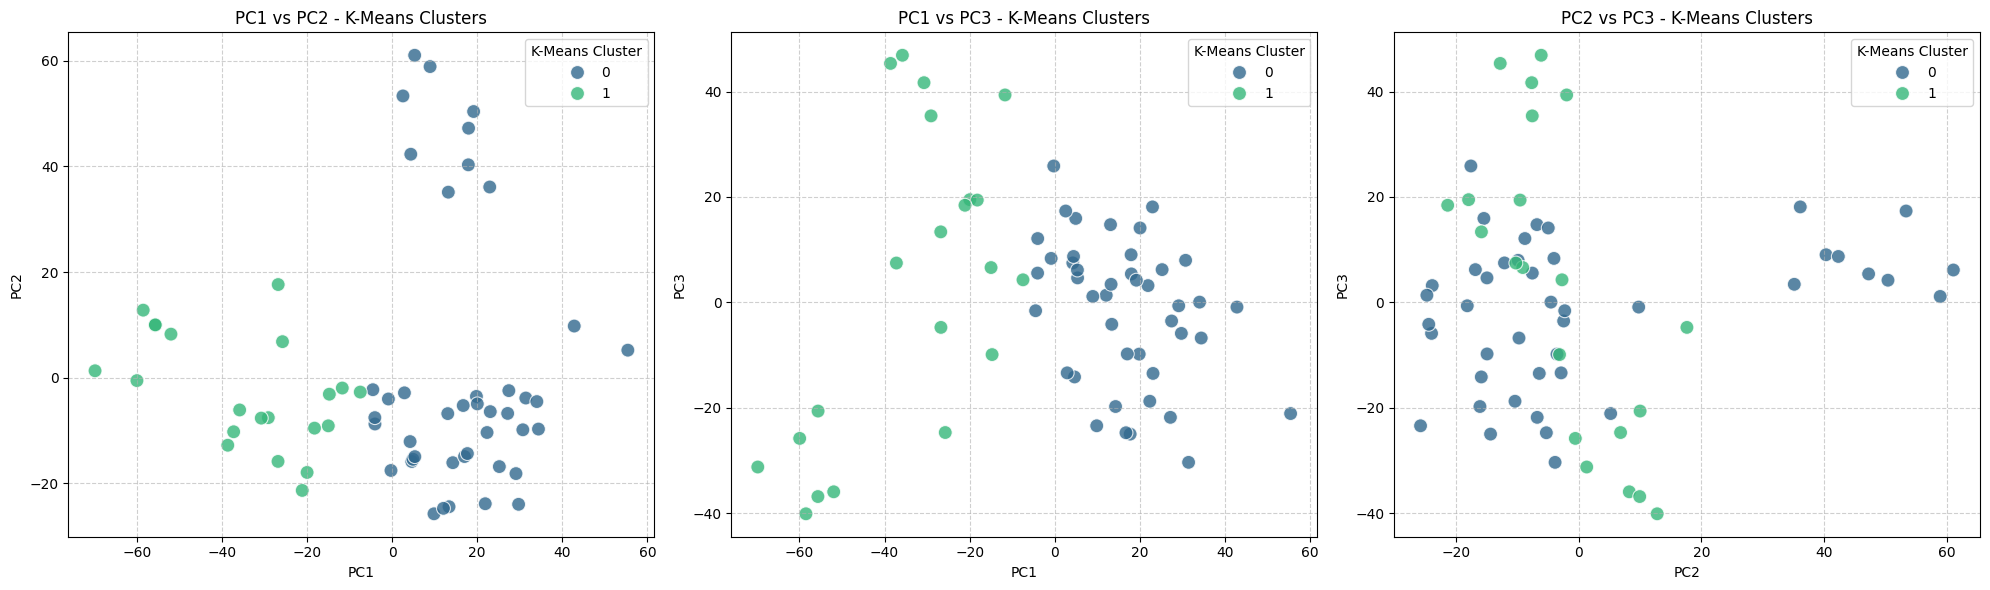

In [ ]:
# Create pairwise scatter plots of the principal components
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
axes = axes.flatten()

# PC1 vs PC2
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='K-Means Cluster',
    palette='viridis',
    s=100,
    alpha=0.8,
    data=pca_df,
    ax=axes[0]
)
axes[0].set_title('PC1 vs PC2 - K-Means Clusters')
axes[0].grid(True, linestyle='--', alpha=0.6)

# PC1 vs PC3
sns.scatterplot(
    x='PC1',
    y='PC3',
    hue='K-Means Cluster',
    palette='viridis',
    s=100,
    alpha=0.8,
    data=pca_df,
    ax=axes[1]
)
axes[1].set_title('PC1 vs PC3 - K-Means Clusters')
axes[1].grid(True, linestyle='--', alpha=0.6)

# PC2 vs PC3
sns.scatterplot(
    x='PC2',
    y='PC3',
    hue='K-Means Cluster',
    palette='viridis',
    s=100,
    alpha=0.8,
    data=pca_df,
    ax=axes[2]
)
axes[2].set_title('PC2 vs PC3 - K-Means Clusters')
axes[2].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

These plots visualize the data in the reduced PCA space. Each scatter plot displays a different pair of principal components (PC1 vs PC2, PC1 vs PC3, PC2 vs PC3), with points colored by their assigned K-Means cluster. This helps to see if the K-Means clusters are well-separated in these lower-dimensional representations of the data.

## Explained Variance Plot with Thresholds

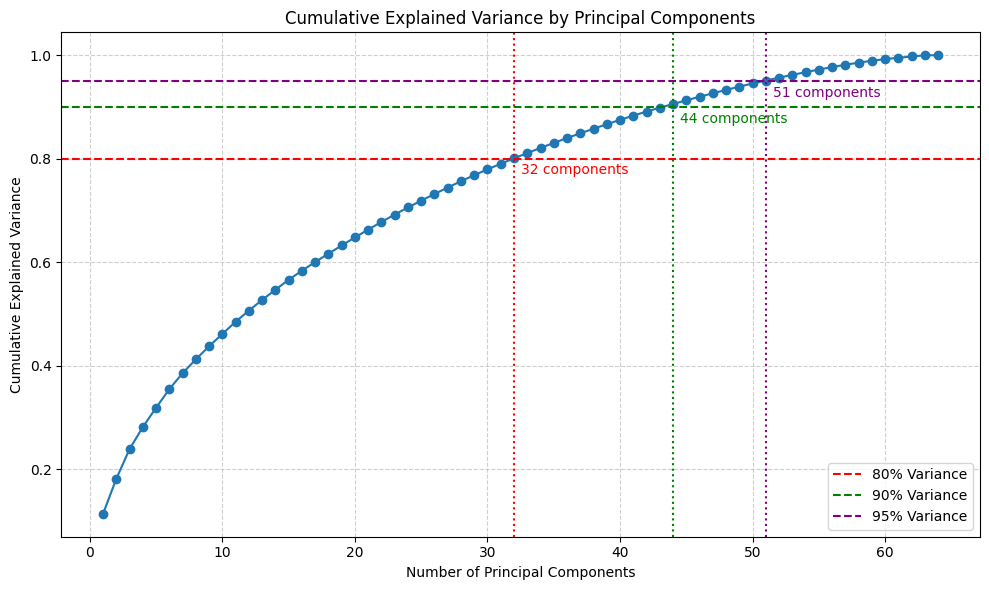

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Calculate explained variance for all components
pca_full = PCA().fit(X_scaled)
explained_variance = pca_full.explained_variance_ratio_
cum_explained_variance = np.cumsum(explained_variance)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cum_explained_variance) + 1), cum_explained_variance, marker='o', linestyle='-')
plt.title('Cumulative Explained Variance by Principal Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True, linestyle='--', alpha=0.6)

# Add threshold lines
thresholds = [0.80, 0.90, 0.95]
colors = ['red', 'green', 'purple']

for threshold, color in zip(thresholds, colors):
    # Find number of components for the threshold
    n_components = np.argmax(cum_explained_variance >= threshold) + 1

    plt.axhline(y=threshold, color=color, linestyle='--', label=f'{int(threshold*100)}% Variance')
    plt.axvline(x=n_components, color=color, linestyle=':')
    plt.text(n_components + 0.5, threshold - 0.03, f'{n_components} components', color=color)

plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Finding Optimal K

How many clusters should we use? The elbow method helps us decide.

This plot shows the cumulative explained variance as the number of principal components increases. The horizontal dashed lines indicate common variance thresholds (80%, 90%, 95%), and the vertical dotted lines show the minimum number of principal components required to achieve that level of explained variance. This helps in deciding how many components to retain for dimensionality reduction while preserving a significant portion of the data's variance.

## K-Means Clustering and Visualization (3 Clusters)

In [ ]:
from sklearn.cluster import KMeans

# Perform K-Means clustering with 3 clusters
kmeans_3 = KMeans(n_clusters=3, n_init=50, random_state=42) # n_init=25 as requested
kmeans_labels_3 = kmeans_3.fit_predict(X)

print(f"K-Means clustering performed with {kmeans_3.n_clusters} clusters.")
print("Cluster assignments (3 clusters):")
print(pd.Series(kmeans_labels_3).value_counts())

K-Means clustering performed with 3 clusters.
Cluster assignments (3 clusters):
1    34
2    21
0     9
Name: count, dtype: int64


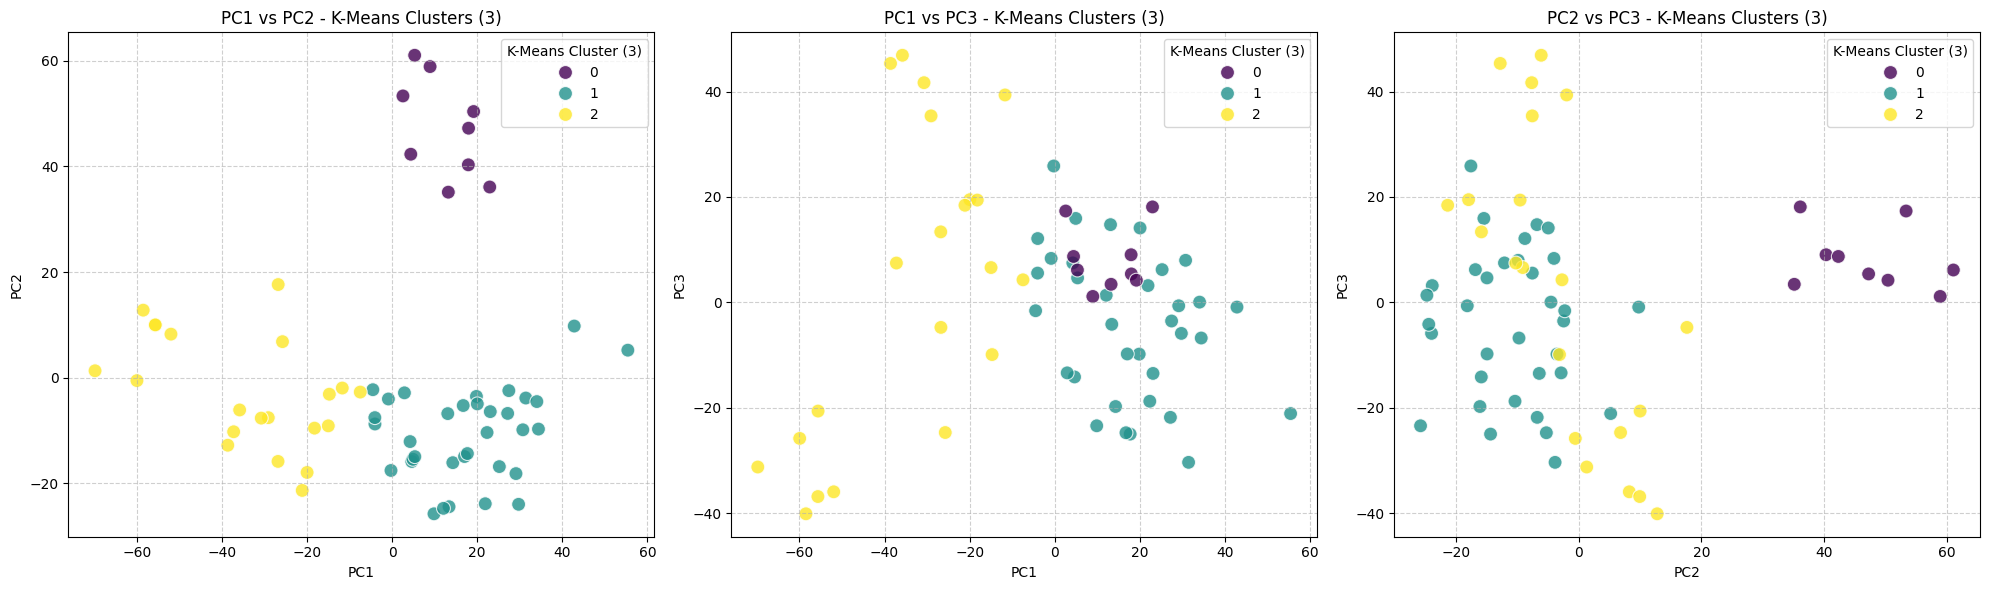

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a DataFrame for PCA results with 3 K-Means clusters
pca_df_3_clusters = pca_df.copy()
pca_df_3_clusters['K-Means Cluster (3)'] = kmeans_labels_3

# Create pairwise scatter plots of the principal components, colored by 3 K-Means clusters
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
axes = axes.flatten()

# PC1 vs PC2
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='K-Means Cluster (3)',
    palette='viridis', # Using a different palette for clusters
    s=100,
    alpha=0.8,
    data=pca_df_3_clusters,
    ax=axes[0]
)
axes[0].set_title('PC1 vs PC2 - K-Means Clusters (3)')
axes[0].grid(True, linestyle='--', alpha=0.6)

# PC1 vs PC3
sns.scatterplot(
    x='PC1',
    y='PC3',
    hue='K-Means Cluster (3)',
    palette='viridis',
    s=100,
    alpha=0.8,
    data=pca_df_3_clusters,
    ax=axes[1]
)
axes[1].set_title('PC1 vs PC3 - K-Means Clusters (3)')
axes[1].grid(True, linestyle='--', alpha=0.6)

# PC2 vs PC3
sns.scatterplot(
    x='PC2',
    y='PC3',
    hue='K-Means Cluster (3)',
    palette='viridis',
    s=100,
    alpha=0.8,
    data=pca_df_3_clusters,
    ax=axes[2]
)
axes[2].set_title('PC2 vs PC3 - K-Means Clusters (3)')
axes[2].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

These plots show the PCA components (PC1 vs PC2, PC1 vs PC3, and PC2 vs PC3), with points colored by the newly assigned K-Means clusters (with 3 clusters). This allows you to visually assess the separation of the data points when grouped into three distinct clusters in the reduced PCA space.

## Cancer Type Distribution per K-Means Cluster (3 Clusters)

In [ ]:
import pandas as pd

# Create a DataFrame to combine K-Means cluster labels and original cancer types
cluster_cancer_df = pd.DataFrame({
    'K-Means Cluster': kmeans_labels_3,
    'Original Cancer Type': y['label'].values
})

# Create a crosstabulation table to show counts of each cancer type per cluster
cancer_type_distribution = pd.crosstab(
    cluster_cancer_df['K-Means Cluster'],
    cluster_cancer_df['Original Cancer Type'],
    rownames=['K-Means Cluster'],
    colnames=['Original Cancer Type']
)

print("Distribution of Cancer Types within each K-Means Cluster (3 Clusters):")
display(cancer_type_distribution)

Distribution of Cancer Types within each K-Means Cluster (3 Clusters):


Original Cancer Type,BREAST,CNS,COLON,K562A-repro,K562B-repro,LEUKEMIA,MCF7A-repro,MCF7D-repro,MELANOMA,NSCLC,OVARIAN,PROSTATE,RENAL,UNKNOWN
K-Means Cluster,,,,,,,,,,,,,,
0,2,0,0,0,0,0,0,0,7,0,0,0,0,0
1,3,5,0,0,0,0,0,0,1,7,6,2,9,1
2,2,0,7,1,1,6,1,1,0,2,0,0,0,0


## Heatmap for Top 40 Differentially Expressed Genes (Two Clusters)

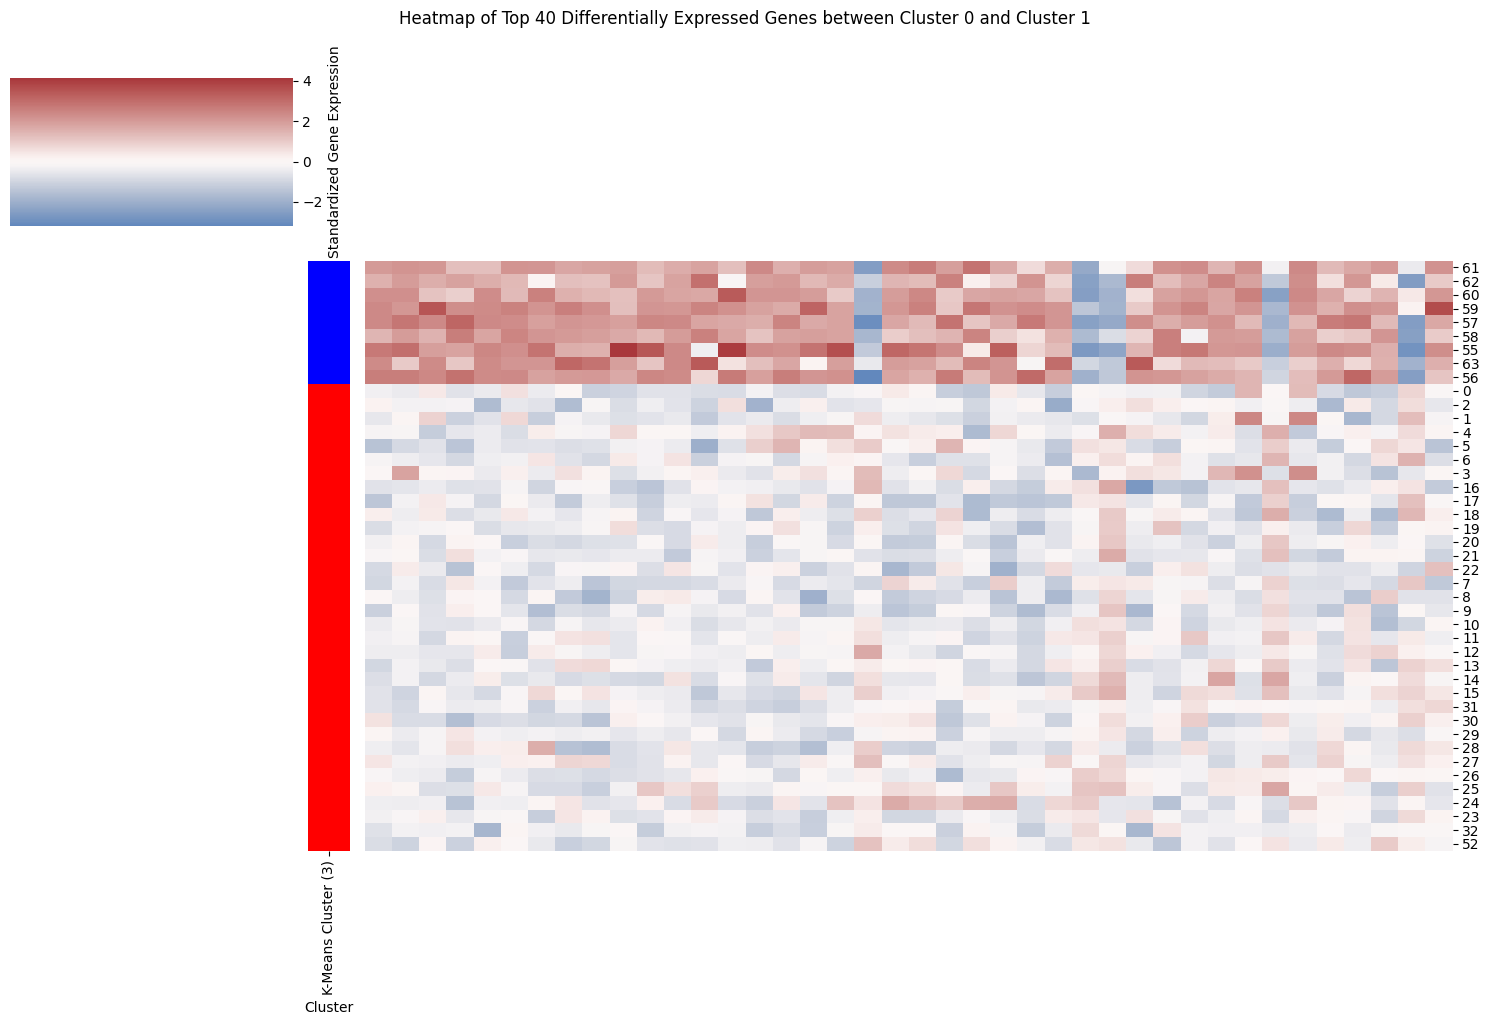

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Select two clusters (e.g., Cluster 0 and Cluster 1)
selected_clusters = [0, 1]

# Create a DataFrame from X_scaled and add the 3-cluster labels
X_scaled_df = pd.DataFrame(X_scaled)
X_scaled_df['K-Means Cluster (3)'] = kmeans_labels_3

# Filter for the selected clusters
df_selected_clusters = X_scaled_df[X_scaled_df['K-Means Cluster (3)'].isin(selected_clusters)].copy()

# Drop the cluster column for gene expression calculation
df_genes_only = df_selected_clusters.drop(columns=['K-Means Cluster (3)'])

# 2. Calculate the average expression per gene for each cluster
cluster_0_avg = df_selected_clusters[df_selected_clusters['K-Means Cluster (3)'] == 0].drop(columns=['K-Means Cluster (3)']).mean()
cluster_1_avg = df_selected_clusters[df_selected_clusters['K-Means Cluster (3)'] == 1].drop(columns=['K-Means Cluster (3)']).mean()

# 3. Calculate the absolute difference between clusters per gene
gene_differences = (cluster_0_avg - cluster_1_avg).abs()

# 4. Select the 40 genes with the largest difference between clusters
top_40_genes_indices = gene_differences.nlargest(40).index

# Get the gene names (column indices) as a list
top_40_genes_col_names = top_40_genes_indices.tolist()

# 5. Prepare data for heatmap: filter for top 40 genes and sort by cluster
heatmap_data = df_selected_clusters[top_40_genes_col_names].copy() # Explicitly create a copy to avoid SettingWithCopyWarning
heatmap_data['K-Means Cluster (3)'] = df_selected_clusters['K-Means Cluster (3)']

# Sort by cluster for better visualization
heatmap_data_sorted = heatmap_data.sort_values(by='K-Means Cluster (3)')

# Extract the cluster labels for annotation
row_colors = heatmap_data_sorted['K-Means Cluster (3)'].map({0: 'blue', 1: 'red'})

# Drop the cluster column from the data used for the heatmap itself
heatmap_matrix = heatmap_data_sorted.drop(columns=['K-Means Cluster (3)'])

# 6. Generate heatmap using clustermap for row_colors functionality
# Clustermap expects samples as rows and features as columns for row_colors
g = sns.clustermap(
    heatmap_matrix, # Use heatmap_matrix directly (samples as rows, genes as columns)
    row_colors=row_colors, # Pass the Series directly, clustermap handles mapping
    cmap='vlag', # Diverging colormap
    center=0,    # Center the colormap at 0 (for standardized data)
    col_cluster=False, # Do not cluster genes
    row_cluster=False, # Do not cluster samples (already sorted by K-Means cluster)
    yticklabels=True, # Show gene names
    xticklabels=False, # Don't show sample labels for clarity
    cbar_kws={'label': 'Standardized Gene Expression'},
    figsize=(15, 10) # Set figure size here for clustermap
)
g.ax_row_colors.set_xlabel('Cluster') # Label for the row colors sidebar
plt.suptitle(f'Heatmap of Top 40 Differentially Expressed Genes between Cluster {selected_clusters[0]} and Cluster {selected_clusters[1]}', y=1.02) # Adjusted title position
plt.tight_layout()
plt.show()

This table provides a clear view of which original cancer types fall into each of the three K-Means clusters. By examining the counts, you can identify if certain clusters are dominated by specific cancer types, giving biological meaning to the unsupervised clustering results.

### 🤔 What Did We Learn?

Looking at these results:
- How do the clusters compare visually?
- Do they make biological sense?
- Where does K-Means struggle?
- What would happen with K=2? K=10?

This heatmap visualizes the expression levels of the top 40 genes that show the largest absolute difference between two selected K-Means clusters (in this case, Cluster 0 and Cluster 1). Each row represents a gene, and each column represents a sample. The samples are sorted by their assigned cluster, and the cluster membership is indicated by the `row_colors` (blue for Cluster 0, red for Cluster 1 on the side bar). A diverging colormap (`vlag`) centered at 0 helps to highlight genes that are highly expressed (red/positive values) or lowly expressed (blue/negative values) relative to the mean across all samples, within each cluster.

---

## 🎓 Key Concepts from K-Means Clustering

### What You've Learned:
1. **Initialization** - Random starting centroids can affect results
2. **Assignment Step** - Points go to nearest centroid
3. **Update Step** - Centroids move to center of their points
4. **Convergence** - Repeat until centroids stop moving
5. **WCSS** - Measure of cluster tightness
6. **Elbow Method** - Finding the right K
7. **Standardization** - Critical preprocessing step

---

## 🚀 Further Learning & Key Concepts

### Practical Next Steps:
1. **Try your own data** - Real learning happens with real problems
2. **Tune n_init** - Use 50-100 for production (we used 25)
3. **Validate clusters** - Do they make sense in your domain?
4. **Combine methods** - K-Means → PCA, or K-Means → Hierarchical
5. **Compare algorithms** - What works best for YOUR problem?